# Celestial Sphere and Sky Coordinates

The **celestial sphere** is an imaginary sphere centered on the observer. Astronomers use it as a map of the sky. It is not a claim that stars are physically attached to a shell. It is a coordinate system that helps us describe where objects appear to be, how they move across the sky, and when they are well placed for observation.

This page focuses on the practical ideas needed for observing, target selection, and reading astronomical coordinates.

```{admonition} Learning goals
:class: note

After working through this page, you should be able to explain the difference between local sky coordinates and equatorial coordinates, identify the zenith, horizon, meridian, celestial equator, celestial poles, and ecliptic, convert right ascension between hours and degrees, explain why right ascension is useful for planning observations, and estimate which right ascensions are best placed in the night sky during different months.
```


## Why the Celestial Sphere Is Useful

The celestial sphere is useful because the sky appears to be a dome above us. Stars are at very different physical distances, but for many observing tasks we only need their **directions** on the sky. We can therefore imagine every object projected onto a large sphere around Earth or around the observer.

Ancient Greek astronomers used this idea in an Earth-centered model of the universe. They observed that the Sun, Moon, planets, and stars rise in the east and set in the west; that constellations keep nearly fixed patterns; and that stars near the north celestial pole circle around a nearly fixed point in the sky. The physical interpretation has changed, but the geometry remains useful. Modern astronomers still use the celestial sphere as a practical mapping tool.

```{admonition} Key idea
:class: tip

The celestial sphere is a model for directions, not distances. It tells you where to look on the sky, not how far away an object is.
```


## The Local Sky: Horizon, Zenith, Nadir, and Meridian

The **local sky** depends on the observer's position on Earth. Two observers at different locations do not have the same horizon, zenith, or local meridian.

The **zenith** is the point directly above the observer. The **nadir** is the point directly below the observer. The **horizon** is the boundary between the visible and invisible sky for that observer. The **local meridian** is the great circle passing through the north point on the horizon, the zenith, the south point on the horizon, and the celestial poles. When an object crosses the local meridian, it is said to **transit** or **culminate**. For most objects, this is when they reach their highest altitude in the sky.

```{admonition} Observing rule
:class: tip

Objects are usually best observed when they are high above the horizon and near the local meridian. Low-altitude objects are seen through more atmosphere, which increases extinction, turbulence, and distortion.
```


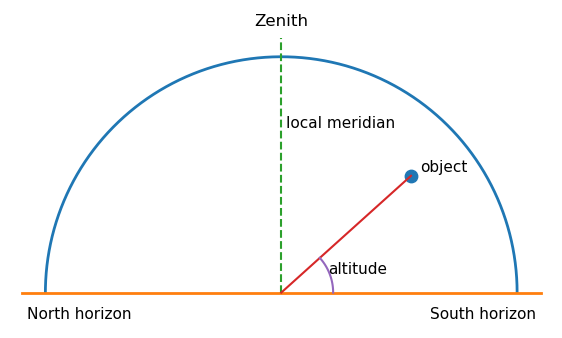

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# This simple diagram shows the local sky as a dome over the observer.
theta = np.linspace(0, np.pi, 300)
x = np.cos(theta)
y = np.sin(theta)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x, y, linewidth=2)
ax.plot([-1.1, 1.1], [0, 0], linewidth=2)
ax.plot([0, 0], [0, 1.08], linestyle="--", linewidth=1.5)

# Example object and altitude angle.
alt_deg = 42
az_projection = 0.55
obj_x = az_projection
obj_y = np.tan(np.deg2rad(alt_deg)) * az_projection
obj_y = min(obj_y, np.sqrt(1 - obj_x**2))
ax.scatter([obj_x], [obj_y], s=80)
ax.plot([0, obj_x], [0, obj_y], linewidth=1.5)

# Draw a small altitude angle arc.
arc_alt = np.linspace(0, np.arctan2(obj_y, obj_x), 100)
r = 0.22
ax.plot(r*np.cos(arc_alt), r*np.sin(arc_alt), linewidth=1.5)
ax.text(0.20, 0.08, "altitude", fontsize=11)

ax.text(0, 1.12, "Zenith", ha="center", va="bottom", fontsize=12)
ax.text(-1.08, -0.06, "North horizon", ha="left", va="top", fontsize=11)
ax.text(1.08, -0.06, "South horizon", ha="right", va="top", fontsize=11)
ax.text(0.02, 0.72, "local meridian", ha="left", va="center", fontsize=11)
ax.text(obj_x + 0.04, obj_y + 0.02, "object", fontsize=11)

ax.set_aspect("equal")
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-0.15, 1.2)
ax.axis("off")
plt.show()

## Horizon Coordinates: Altitude and Azimuth

The **altitude-azimuth system** describes where an object appears in your local sky right now. It is useful when you are physically pointing a telescope, binoculars, or your eyes.

**Altitude** is the angular height of an object above the horizon. An object on the horizon has altitude $0^{\circ}$, an object at the zenith has altitude $90^{\circ}$, and an object below the horizon has negative altitude. **Azimuth** is the direction around the horizon, usually measured clockwise from north. In the common astronomy convention, north is $0^{\circ}$, east is $90^{\circ}$, south is $180^{\circ}$, and west is $270^{\circ}$.

Altitude and azimuth are local and time-dependent. The same star has different altitude and azimuth values for different observers, and the values change continuously as Earth rotates.

```{admonition} Common beginner mistake
:class: warning

Altitude and azimuth are not permanent coordinates for a star. They tell you where the star is from one location at one time.
```


## Equatorial Coordinates: Right Ascension, Declination, and Epoch

Astronomers use the **equatorial coordinate system** to give objects a more stable address on the sky. It is similar in spirit to longitude and latitude on Earth, but it is projected onto the celestial sphere.

**Declination**, written as Dec or $\delta$, measures angular distance north or south of the celestial equator. It is analogous to latitude. The celestial equator has $\delta = 0^{\circ}$, the north celestial pole has $\delta = +90^{\circ}$, and the south celestial pole has $\delta = -90^{\circ}$.

**Right ascension**, written as RA or $\alpha$, measures angle eastward along the celestial equator from the vernal equinox. It is analogous to longitude, but it is usually measured in hours, minutes, and seconds instead of degrees. The full circle is $24{\rm h}$, so $1{\rm h}$ of RA corresponds to $15^{\circ}$.

$$1{\rm h} = 15^{\circ}$$

The **epoch** tells you the reference date for the coordinate grid. This matters because Earth's rotation axis slowly precesses, causing the celestial poles and equator to drift over time. Many catalogs report coordinates at epoch **J2000.0**, which refers to January 1, 2000, at 12:00 Terrestrial Time. For most introductory observing tasks, J2000 coordinates are fine. For precise pointing, long time baselines, or high proper-motion stars, the epoch matters.

```{admonition} Practical distinction
:class: tip

Use RA and Dec to identify a target in a catalog. Use altitude and azimuth to know where to look from a specific observing site at a specific time.
```


In [ ]:
# Right ascension is often written in hours, minutes, and seconds.
# This helper converts RA from h:m:s to degrees.

def ra_hms_to_degrees(hours, minutes=0, seconds=0):
    """Convert right ascension from hours, minutes, seconds to degrees."""
    return 15 * (hours + minutes/60 + seconds/3600)

def degrees_to_ra_hms(degrees):
    """Convert right ascension from degrees to hours, minutes, seconds."""
    total_hours = (degrees / 15) % 24
    hours = int(total_hours)
    total_minutes = (total_hours - hours) * 60
    minutes = int(total_minutes)
    seconds = (total_minutes - minutes) * 60
    return hours, minutes, seconds

ra_deg = ra_hms_to_degrees(5, 35, 17.3)
h, m, s = degrees_to_ra_hms(ra_deg)

print(f"RA = 5h 35m 17.3s corresponds to {ra_deg:.3f} degrees.")
print(f"{ra_deg:.3f} degrees corresponds to RA = {h}h {m}m {s:.1f}s.")

RA = 5h 35m 17.3s corresponds to 83.822 degrees.
83.822 degrees corresponds to RA = 5h 35m 17.3s.


## Earth Rotation, Sidereal Time, and Hour Angle

The sky appears to rotate because Earth rotates. A star's RA does not change during the night, but its location in the local sky does. The connection between catalog coordinates and local observing geometry is made using **local sidereal time** and **hour angle**.

The **local sidereal time** is the right ascension currently crossing your local meridian. If the local sidereal time is $10{\rm h}$, then objects with $\alpha \approx 10{\rm h}$ are near the meridian. The **hour angle** $H$ tells how far an object is from the meridian:

$$H = {\rm LST} - \alpha.$$

An object with $H=0$ is on the meridian. Negative hour angle usually means the object is east of the meridian and will transit later. Positive hour angle usually means the object is west of the meridian and has already transited.

For an observer at latitude $\phi$, an object with declination $\delta$ has altitude $h$ given by

$$\sin h = \sin\phi\sin\delta + \cos\phi\cos\delta\cos H.$$

This equation is useful because it connects an object's fixed sky address, RA and Dec, to its altitude from a specific observing site at a specific time.


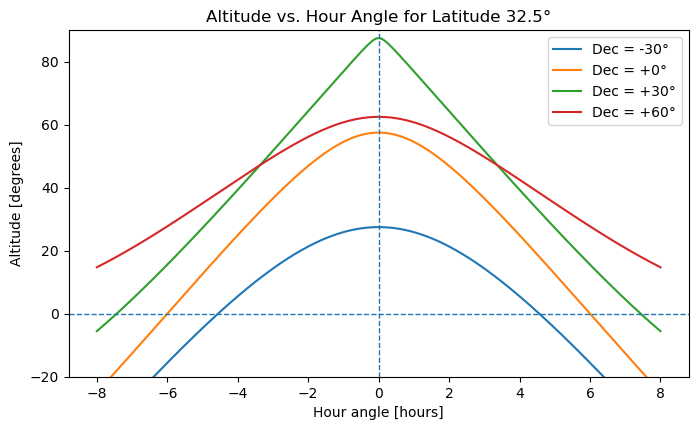

In [ ]:
# Altitude of a target as a function of hour angle.
# This is useful for understanding why objects are best observed near meridian transit.

def altitude_at_hour_angle(latitude_deg, dec_deg, hour_angle_hours):
    """
    Compute altitude in degrees for an object observed from latitude_deg,
    with declination dec_deg, at a given hour angle in hours.
    """
    phi = np.deg2rad(latitude_deg)
    dec = np.deg2rad(dec_deg)
    H = np.deg2rad(15 * hour_angle_hours)

    sin_alt = np.sin(phi)*np.sin(dec) + np.cos(phi)*np.cos(dec)*np.cos(H)
    return np.rad2deg(np.arcsin(sin_alt))

latitude_deg = 32.5  # approximate latitude for northeast Texas
hour_angle = np.linspace(-8, 8, 400)

fig, ax = plt.subplots(figsize=(8, 4.5))

for dec_deg in [-30, 0, 30, 60]:
    alt = altitude_at_hour_angle(latitude_deg, dec_deg, hour_angle)
    ax.plot(hour_angle, alt, label=f"Dec = {dec_deg:+.0f}°")

ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Hour angle [hours]")
ax.set_ylabel("Altitude [degrees]")
ax.set_title(f"Altitude vs. Hour Angle for Latitude {latitude_deg:.1f}°")
ax.set_ylim(-20, 90)
ax.legend()
plt.show()

## Celestial Poles, Celestial Equator, and Observer Latitude

The **north celestial pole** is the point in the sky directly above Earth's north geographic pole. The **south celestial pole** is directly above Earth's south geographic pole. The **celestial equator** is the projection of Earth's equator onto the sky.

A useful observing fact is that the altitude of the visible celestial pole equals the observer's latitude. For example, at latitude $32.5^{\circ}{\rm N}$, the north celestial pole is about $32.5^{\circ}$ above the northern horizon. This is why Polaris appears higher in the sky for observers farther north and lower in the sky for observers farther south.

```{admonition} Checkpoint
:class: tip

If you observe from latitude $40^{\circ}{\rm N}$, what is the approximate altitude of the north celestial pole? What would happen to that altitude if you traveled south toward the equator?
```


## The Ecliptic and the Sun's Apparent Path

The **ecliptic** is the Sun's apparent annual path across the celestial sphere. It is tilted by about $23.5^{\circ}$ relative to the celestial equator because Earth's rotation axis is tilted relative to its orbital plane.

The Moon and planets are usually found near the ecliptic because the Solar System is relatively flat. They are not exactly on the ecliptic, but the ecliptic is a useful guide when looking for planets in the sky.

The ecliptic also explains why the Sun's right ascension changes throughout the year. Around the March equinox, the Sun has RA near $0{\rm h}$. Around the June solstice, it has RA near $6{\rm h}$. Around the September equinox, it has RA near $12{\rm h}$. Around the December solstice, it has RA near $18{\rm h}$.


## Planning Observations with Right Ascension

For nighttime observing, the best-placed targets are usually those high in the sky during the dark part of the night. Around local midnight, the sky on the meridian is roughly opposite the Sun. Therefore, the best right ascension for midnight observing is approximately

$$\alpha_{\rm best} \approx \alpha_{\odot} + 12{\rm h}.$$

This rule is approximate. The best target also depends on your observing site, the target declination, moonlight, weather, telescope limits, and the time of night you plan to observe.  

<center>

| Month | Sun's approximate RA | RA best placed near midnight |
|---|---:|---:|
| January | $19{\rm h}$ to $21{\rm h}$ | $7{\rm h}$ to $9{\rm h}$ |
| February | $21{\rm h}$ to $23{\rm h}$ | $9{\rm h}$ to $11{\rm h}$ |
| March | $23{\rm h}$ to $1{\rm h}$ | $11{\rm h}$ to $13{\rm h}$ |
| April | $1{\rm h}$ to $3{\rm h}$ | $13{\rm h}$ to $15{\rm h}$ |
| May | $3{\rm h}$ to $5{\rm h}$ | $15{\rm h}$ to $17{\rm h}$ |
| June | $5{\rm h}$ to $7{\rm h}$ | $17{\rm h}$ to $19{\rm h}$ |
| July | $7{\rm h}$ to $9{\rm h}$ | $19{\rm h}$ to $21{\rm h}$ |
| August | $9{\rm h}$ to $11{\rm h}$ | $21{\rm h}$ to $23{\rm h}$ |
| September | $11{\rm h}$ to $13{\rm h}$ | $23{\rm h}$ to $1{\rm h}$ |
| October | $13{\rm h}$ to $15{\rm h}$ | $1{\rm h}$ to $3{\rm h}$ |
| November | $15{\rm h}$ to $17{\rm h}$ | $3{\rm h}$ to $5{\rm h}$ |
| December | $17{\rm h}$ to $19{\rm h}$ | $5{\rm h}$ to $7{\rm h}$ |

</center>

For example, in May, objects with RA near $15{\rm h}$ to $17{\rm h}$ are well placed near midnight. Objects with smaller RA may be better earlier in the evening, while objects with larger RA may be better later at night.


In [ ]:
# A small helper for wrapping right ascension values into the range 0h to 24h.
months = [
    ("January", 20), ("February", 22), ("March", 0), ("April", 2),
    ("May", 4), ("June", 6), ("July", 8), ("August", 10),
    ("September", 12), ("October", 14), ("November", 16), ("December", 18),
]

def wrap_ra_hours(ra_hours):
    return ra_hours % 24

print("Approximate midnight observing guide")
print("------------------------------------")
for month, sun_ra in months:
    best_ra = wrap_ra_hours(sun_ra + 12)
    print(f"{month:9s}: Sun RA ≈ {sun_ra:2.0f}h, best midnight RA ≈ {best_ra:2.0f}h")

Approximate midnight observing guide
------------------------------------
January  : Sun RA ≈ 20h, best midnight RA ≈  8h
February : Sun RA ≈ 22h, best midnight RA ≈ 10h
March    : Sun RA ≈  0h, best midnight RA ≈ 12h
April    : Sun RA ≈  2h, best midnight RA ≈ 14h
May      : Sun RA ≈  4h, best midnight RA ≈ 16h
June     : Sun RA ≈  6h, best midnight RA ≈ 18h
July     : Sun RA ≈  8h, best midnight RA ≈ 20h
August   : Sun RA ≈ 10h, best midnight RA ≈ 22h
September: Sun RA ≈ 12h, best midnight RA ≈  0h
October  : Sun RA ≈ 14h, best midnight RA ≈  2h
November : Sun RA ≈ 16h, best midnight RA ≈  4h
December : Sun RA ≈ 18h, best midnight RA ≈  6h


## Python Packages for Planning Observations

The ideas in this chapter become more useful when they are connected to observation planning. For real observing, you usually want to answer questions like: When is my target above the horizon? When is it high enough to observe? When is the Sun down? Is the target visible during astronomical twilight? What does the field look like on the sky?

Python has several packages that help with these questions.

| Package | What it is useful for | What a beginner should remember |
|---|---|---|
| `astropy` | Coordinates, times, units, observatory locations, and transformations between coordinate systems | This is the foundation package for most astronomy calculations in Python. |
| `astroplan` | Observation planning, including observers, targets, twilight times, airmass plots, and observability constraints | Use this when you want to know whether a target is observable from a site on a specific night. |
| `matplotlib` | Plotting altitude, airmass, light curves, and observing windows | Use this to make saved figures for a research log or observing plan. |
| `ipyaladin` | Interactive finder charts in Jupyter notebooks using Aladin Lite | Use this when you want to inspect the sky around a target interactively. |
| `ipywidgets` | Interactive notebook controls such as dropdown menus, sliders, and side-by-side layouts | Useful later, but not required for a first observation-planning example. |

The simplified workflow is:

1. Define the observing site.
2. Define the target position.
3. Choose an observing date.
4. Compute sunset, sunrise, and twilight times.
5. Plot target airmass or altitude through the night.
6. Optionally open a finder chart to inspect the field.

The example below uses a fixed coordinate for the target instead of resolving the target name online. This makes the example more reliable in a teaching notebook because it does not depend on an internet name-resolution query.

Observing site: Kitt Peak
Target: Vega
Sunset: 2026-07-02 02:31:56.984 UTC
Astronomical twilight ends: 2026-07-02 04:15:57.561 UTC
Astronomical twilight begins: 2026-07-02 10:45:03.089 UTC
Sunrise: 2026-07-02 12:29:01.892 UTC


c:\Users\satur\anaconda3\Lib\site-packages\matplotlib\dates.py:449: UserWarning: no explicit representation of timezones available for np.datetime64
  d = d.astype('datetime64[us]')


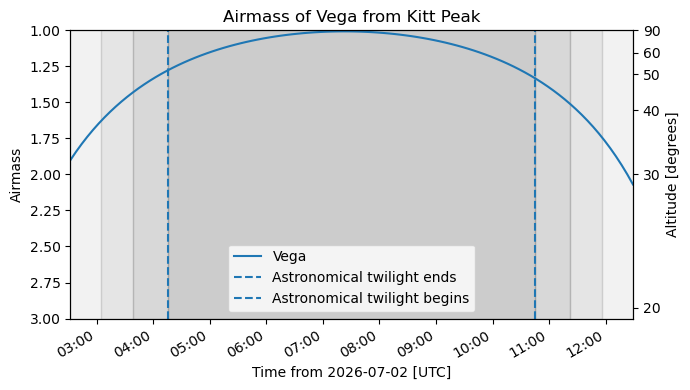

In [5]:
# Optional example: basic observation planning with astroplan.
#
# This cell is written so the notebook can still run even if astroplan
# is not installed in the current environment.

try:
    import numpy as np
    import matplotlib.pyplot as plt

    from astropy import units as u
    from astropy.coordinates import EarthLocation, SkyCoord
    from astropy.time import Time

    from astroplan import Observer, FixedTarget
    from astroplan.plots import plot_airmass

except ImportError as err:
    print("This optional example requires astropy, astroplan, numpy, and matplotlib.")
    print("Install the missing package in a local environment before running this cell.")
    print(f"Missing package message: {err}")

else:
    # 1. Define an observing site.
    # These are approximate coordinates for Kitt Peak National Observatory.
    kpno_location = EarthLocation.from_geodetic(lon=-111.600 * u.deg, lat=31.958 * u.deg, height=2096 * u.m)

    observer = Observer(location=kpno_location, name="Kitt Peak", timezone="US/Arizona")

    # 2. Define a target using fixed coordinates.
    # Vega is used here only as a familiar example target.
    target_coord = SkyCoord("18h36m56.3s", "+38d47m01s", frame="icrs")
    target = FixedTarget(coord=target_coord, name="Vega")

    # 3. Choose an observing date.
    # The time is in UTC. This example starts near the evening of 2026 July 1
    # for a North American observing site.
    observing_time = Time("2026-07-02 04:00:00")

    # 4. Compute approximate night boundaries.
    sunset = observer.sun_set_time(observing_time, which="nearest")
    sunrise = observer.sun_rise_time(observing_time, which="next")
    astro_dark_start = observer.twilight_evening_astronomical(observing_time, which="nearest")
    astro_dark_end = observer.twilight_morning_astronomical(observing_time, which="next")

    print(f"Observing site: {observer.name}")
    print(f"Target: {target.name}")
    print(f"Sunset: {sunset.iso} UTC")
    print(f"Astronomical twilight ends: {astro_dark_start.iso} UTC")
    print(f"Astronomical twilight begins: {astro_dark_end.iso} UTC")
    print(f"Sunrise: {sunrise.iso} UTC")

    # 5. Make an airmass plot from sunset to sunrise.
    hours = np.linspace(0, (sunrise - sunset).to_value(u.hour), 100)
    times = sunset + hours * u.hour

    fig, ax = plt.subplots(figsize=(7, 4))
    plot_airmass(target, observer, times, ax=ax, max_airmass=3.0, brightness_shading=True, altitude_yaxis=True)

    ax.axvline(astro_dark_start.datetime, linestyle="--", label="Astronomical twilight ends")
    ax.axvline(astro_dark_end.datetime, linestyle="--", label="Astronomical twilight begins")
    ax.set_title(f"Airmass of {target.name} from {observer.name}")
    ax.legend()
    fig.tight_layout()

    plt.show()

### Optional finder chart with `ipyaladin`

An airmass plot tells you **when** the target is observable. A finder chart helps you inspect **where** the target is on the sky and what the nearby field looks like. The `ipyaladin` widget is useful for this in a live Jupyter notebook.

This kind of cell may not display in every static Jupyter Book build. It is mainly for an interactive notebook session.

In [6]:
# Optional interactive finder chart with ipyaladin.
#
# This cell works in a live Jupyter notebook environment when ipyaladin is installed.
# It may not render as an interactive widget in a static web page.

try:
    from ipyaladin import Aladin

except ImportError as err:
    print("This optional finder-chart example requires ipyaladin.")
    print("Install ipyaladin in a local Jupyter environment before running this cell.")
    print(f"Missing package message: {err}")

else:
    Aladin(target="Vega", fov=0.25, survey="P/DSS2/color", reticle_color="red", reticle_size=24, layout={"width": "700px", "height": "450px"})

### What to record in an observing-plan log

When you use software to plan observations, record the important choices. A useful log entry should say which site you used, which target coordinates you used, which date you planned for, which filters or exposure times you considered, and which figure or finder chart you saved.

```markdown
## Observation planning log

Date planned:
- 2026-07-01

Observing site:
- Kitt Peak National Observatory

Target:
- Vega
- RA: 18h36m56.3s
- Dec: +38d47m01s

Software:
- `astropy`
- `astroplan`
- `matplotlib`
- optional: `ipyaladin`

Result:
- The target is observable during the night and reaches low airmass.
- Airmass plot created in the notebook.

Next step:
- Replace the example target with the science target and save the airmass plot in `figures/`.
```

The most common beginner mistake is to save the plot but not record the observing site, date, target coordinates, or time zone. Without those details, the plot is hard to interpret later.

## Optional Python: Using Astropy for Real Observing Calculations

The previous examples show the geometry using simple equations. For real observing plans, astronomers often use **Astropy**, which can account for time, location, coordinate frames, and object coordinates more systematically.

The cell below is written so that it does not crash if Astropy is not installed. In a fresh Colab notebook, you may need to install it first using `pip install astropy`.


In [ ]:
# Optional example. This cell gives a real Alt/Az calculation if Astropy is installed.
# If Astropy is not installed, it prints instructions instead of failing.

try:
    import astropy.units as u
    from astropy.coordinates import SkyCoord, EarthLocation, AltAz
    from astropy.time import Time

    # Example observing site near northeast Texas.
    location = EarthLocation(lat=32.5*u.deg, lon=-95.0*u.deg, height=150*u.m)

    # Example target coordinates.
    target = SkyCoord(ra="15h00m00s", dec="+30d00m00s", frame="icrs")

    # Example observing time in UTC.
    time = Time("2026-05-18 05:00:00", scale="utc")

    altaz_frame = AltAz(obstime=time, location=location)
    target_altaz = target.transform_to(altaz_frame)

    print(f"Target altitude: {target_altaz.alt:.2f}")
    print(f"Target azimuth:  {target_altaz.az:.2f}")

except ModuleNotFoundError:
    print("Astropy is not installed in this environment.")
    print("To run this example in Colab or Jupyter, install Astropy first:")
    print("    pip install astropy")

Target altitude: 81.56 deg
Target azimuth:  105.51 deg


## Supplemental Videos

These videos are optional review resources. They are not a substitute for doing the coordinate and observing-planning exercises, but they can help if the geometry, time systems, or observing workflow feels unfamiliar. Use them selectively: if you are confused about **where an object is in your local sky**, start with the Alt/Az videos; if you are confused about **how catalogs list object positions**, start with the equatorial-coordinate and catalog videos; if you are confused about **when an object is observable**, review sidereal time, hour angle, and astronomical time systems.

### Local sky and horizon coordinates

- [The Sky Part 1: Local Sky and Alt-Az / Horizon Coordinates](https://www.youtube.com/watch?v=i2e0aRtwsCY), Launch Pad Astronomy  
  Best match for horizon, zenith, altitude, azimuth, and the observer-centered sky.

- [The Sky Part 2: Explaining Alt Az](https://www.youtube.com/results?search_query=Launch+Pad+Astronomy+The+Sky+Part+2+Explaining+Alt+Az), Launch Pad Astronomy  
  Useful follow-up if altitude and azimuth still feel abstract.

### Equatorial coordinates and the celestial sphere

- [Equatorial Coordinate System Explained: How Astronomers Navigate the Celestial Sphere](https://www.youtube.com/watch?v=WvXTUcYVXzI), Launch Pad Astronomy  
  Best match for right ascension, declination, and why astronomers use coordinates fixed to the sky.

- [Celestial Coordinates Guide for Astronomers](https://www.youtube.com/watch?v=jkrw6tObCKk)  
  A practical amateur-astronomy-style overview of RA/Dec and using coordinates to find objects.

- [Lesson 2 - Lecture 1 - The Celestial Sphere - OpenStax](https://www.youtube.com/watch?v=BmyEOpJRxJM)  
  Longer lecture-style review of the celestial sphere.

- [Lesson 4 - Lecture 1 - Coordinate Systems - OpenStax](https://www.youtube.com/watch?v=3OlDsAsOBWI)  
  Longer lecture-style review of astronomical coordinate systems.

### Sidereal time, hour angle, and sky motion

- [Cycles in the Sky: Crash Course Astronomy #3](https://www.youtube.com/watch?v=01QWC-rZcfE), Crash Course Astronomy  
  Good broad review of repeated sky motions and why the sky changes over time.

- [Astronomy GCSE Topic 6 Local Sidereal Time](https://www.youtube.com/watch?v=wygtuSCwrNM)  
  Useful if you need a slower explanation of why local sidereal time is connected to what is crossing the meridian.

### Astronomical time systems and observing dates

Boyce Astro has several short videos that are useful once students begin planning observations or reading light-curve data products. These are especially useful because observational astronomy often uses time systems that are not the same as ordinary clock time.

- [What is Time from an Astronomical Perspective](https://boyce-astro.org/what-is-time-from-an-astronomical-perspective/), Boyce Astro  
  Use this as a general introduction to why astronomy has multiple time scales.

- [What is Time: JD](https://boyce-astro.org/what-is-time-jd/), Boyce Astro  
  Useful when students first encounter Julian Date in FITS headers, observing logs, or time-series data.

- [What is Time: BJD](https://boyce-astro.org/what-is-time-bjd/), Boyce Astro  
  Useful when students encounter barycentric timing in exoplanet or variable-star light curves.

- [What is an Ephemeris](https://boyce-astro.org/what-is-an-ephemeris/), Boyce Astro  
  Useful for connecting period, phase, predicted event times, and observing windows.

- [What is an Epoch](https://boyce-astro.org/what-is-an-epoch-2/), Boyce Astro  
  Useful for understanding reference dates in coordinates, orbits, and time-dependent astronomical quantities.

### Finding targets, catalogs, and finder charts

These videos connect directly to the observing-planning examples in this notebook. They are useful when a target name has to be turned into coordinates, a finder chart, or a field that can actually be observed.

- [Online Catalogs Overview](https://boyce-astro.org/online-catalogs-overview/), Boyce Astro  
  Good orientation to common catalog tools such as CDS, VizieR, and SIMBAD.

- [SIMBAD](https://boyce-astro.org/simbad/), Boyce Astro  
  Useful for looking up object names, coordinates, identifiers, and literature references.

- [Locating Your Star in an Image Using Astrometry.net and DS9](https://boyce-astro.org/locating-your-star-in-an-image-using-astrometry-net-and-ds9/), Boyce Astro  
  Useful once students move from catalog coordinates to actual images and need to confirm which star is the target.

- [Locating your star in an image - Variable Stars and Exoplanets](https://boyce-astro.org/locating-your-star-in-an-image-variable-stars-and-exoplanets/), Boyce Astro  
  Useful for connecting target identification to variable-star or exoplanet-style observing projects.

### Ecliptic, seasons, and the Sun's apparent path

- [Understanding the Sun's Motion and the Reason for Seasons](https://www.youtube.com/watch?v=6-Zm1wzuR-s), Launch Pad Astronomy  
  Useful review for the Sun's path, seasonal changes, and why the ecliptic matters.

- [The Ecliptic: Crash Course Kids #37.2](https://www.youtube.com/watch?v=vYxps00Ap9s), Crash Course Kids  
  Short and simple review of the ecliptic. This is below college level, but it is a useful quick visual reminder.

### Telescopes, photometry, and light curves

These are not required for understanding the celestial sphere itself, but they are helpful for students who will use coordinates to plan real observations or interpret time-series data.

- [Telescopes: An Overview](https://boyce-astro.org/telescopes-an-overview/), Boyce Astro  
  Useful for basic telescope vocabulary such as aperture and field of view.

- [Photometry an Overview](https://boyce-astro.org/photometry-an-overview/), Boyce Astro  
  Useful for understanding why repeated brightness measurements are scientifically useful.

- [Flow of A Photometry Project](https://boyce-astro.org/flow-of-a-photometry-project/), Boyce Astro  
  Useful for seeing how target selection, imaging, measurement, and analysis fit together in a complete project.

- [Overview of a Light Curve](https://boyce-astro.org/overview-of-a-light-curve/), Boyce Astro  
  Useful when connecting observing windows to brightness versus time data.

- [Light Curve Analysis](https://boyce-astro.org/light-curve-analysis/), Boyce Astro  
  Useful follow-up for students who will analyze variable-star or exoplanet time-series data.

- [The Weird and Wonderful World of Exoplanet Data](https://boyce-astro.org/the-weird-and-wonderful-world-of-exoplanet-data/), Boyce Astro  
  Useful broader context for students interested in TESS, exoplanet transits, and real observing data.

```{admonition} How to use these videos
:class: tip

Do not try to watch everything at once. Choose one short cluster based on the problem you are having: sky geometry, coordinate systems, time systems, target lookup, or light-curve context. After watching, return to the notebook and test the idea with one concrete target.
```


## Common Mistakes

A common mistake is to confuse RA and altitude. RA is part of a catalog coordinate system. Altitude is a local sky coordinate that changes throughout the night. Another common mistake is to assume that a target with a good RA is automatically observable. Declination matters too. A target can have the right RA for the month but still be too far south, too low above the horizon, too close to the Sun, or poorly placed during the available observing window.

Students also often forget that "best RA by month" is only a planning shortcut. Real observation planning should check altitude versus time, twilight, moonlight, airmass, telescope limits, exposure time, and target priority.

```{admonition} Practical checklist
:class: tip

Before choosing a target for an observing run, check its RA, Dec, altitude during the observing window, time of meridian transit, angular separation from the Moon, expected brightness, required filter or instrument setup, and whether the target is scientifically useful for the project.
```


## Summary Rules

The celestial sphere is a map of directions on the sky. Horizon coordinates, altitude and azimuth, describe where an object is in the local sky at a specific time. Equatorial coordinates, right ascension and declination, give a more stable catalog address for an object. Earth rotation connects the two systems through sidereal time and hour angle.

```{admonition} Final rules
:class: tip

Use **RA and Dec** to identify targets in catalogs.

Use **altitude and azimuth** to point or visualize the local sky.

Use **hour angle and meridian transit** to decide when a target is highest.

Use **RA by month** only as a first-pass observing guide, not as a substitute for an altitude versus time check.
```


## Checkpoint Questions

1. Why is the celestial sphere still useful even though stars are not physically attached to a sphere around Earth?
2. What is the difference between altitude and declination?
3. If a star has altitude $20^{\circ}$, is it high or low in the sky? Why might that matter for observations?
4. If the local sidereal time is $8{\rm h}$, which right ascension is crossing the local meridian?
5. Around which month are objects with RA near $16{\rm h}$ well placed near midnight?
6. Why is it not enough to choose targets using RA alone?
